In [1]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize

sns.set_style("whitegrid")

In [2]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("vader_lexicon")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hheyk\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hheyk\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hheyk\AppData\Roaming\nltk_data...


True

In [3]:
complaints = pd.read_csv("../data/processed/complaints_sample.csv")
complaints.head()

,product,issue,complaint_text,company,state,date_received
0,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,Subject : Complaint Against PNC Bank for Unres...,PNC Bank N.A.,MD,2024-11-25
1,Credit reporting or other personal consumer re...,Incorrect information on your report,XXXX contact XXXX bank to verify an account th...,"EQUIFAX, INC.",LA,2023-11-21
2,"Money transfer, virtual currency, or money ser...",Unauthorized transactions or other transaction...,Im a trader of Bitcoin on the platform XXXX. I...,"Paypal Holdings, Inc",GA,2022-08-24
3,Checking or savings account,Managing an account,I deposited a check to XXXX XXXX because the c...,UNITED SERVICES AUTOMOBILE ASSOCIATION,NY,2021-11-11
4,"Money transfer, virtual currency, or money ser...",Other transaction problem,I am filing a complaint against cash app ( Blo...,"Block, Inc.",MO,2025-02-24


In [4]:
complaints.info()
complaints.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   product         20000 non-null  str  
 1   issue           20000 non-null  str  
 2   complaint_text  20000 non-null  str  
 3   company         20000 non-null  str  
 4   state           19921 non-null  str  
 5   date_received   20000 non-null  str  
dtypes: str(6)
memory usage: 937.6 KB


product            0
issue              0
complaint_text     0
company            0
state             79
date_received      0
dtype: int64

In [5]:
complaints = complaints.dropna(subset=["complaint_text"]).copy()
complaints = complaints[complaints["complaint_text"].str.strip() != ""]
complaints.shape

(20000, 6)

In [6]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(rf"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

In [8]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hheyk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hheyk\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [9]:
complaints["clean_text"] = complaints["complaint_text"].apply(clean_text)
complaints[["complaint_text", "clean_text"]].head()

,complaint_text,clean_text
0,Subject : Complaint Against PNC Bank for Unres...,subject complaint pnc bank unresolved atm depo...
1,XXXX contact XXXX bank to verify an account th...,xxxx contact xxxx bank verify account showing ...
2,Im a trader of Bitcoin on the platform XXXX. I...,trader bitcoin platform xxxx opened venmo acco...
3,I deposited a check to XXXX XXXX because the c...,deposited check xxxx xxxx check amount limited...
4,I am filing a complaint against cash app ( Blo...,filing complaint cash app block inc due inadeq...


In [10]:
complaints["clean_text"].str.len().describe()

count    20000.000000
mean       677.839650
std        888.625022
min          4.000000
25%        227.000000
50%        446.000000
75%        805.000000
max      22498.000000
Name: clean_text, dtype: float64

In [11]:
for i in range(3):
    print("RAW:", complaints.iloc[i]["complaint_text"][:300])
    print("CLEAN:", complaints.iloc[i]["clean_text"][:300])
    print("-" * 80)

RAW: Subject : Complaint Against PNC Bank for Unresolved ATM Deposit Issue Details of the Complaint : On XX/XX/XXXX, I deposited {$760.00} into a PNC Bank ATM in XXXX XXXXXXXX XXXX but the transaction was canceled, and the money became stuck inside the machine. Since that day, I have not been able to ret
CLEAN: subject complaint pnc bank unresolved atm deposit issue details complaint xxxx deposited pnc bank atm xxxx xxxxxxxx xxxx transaction canceled money became stuck inside machine since day able retrieve funds promptly filed claim pnc bank day however used xxxx xxxx xxxx card deposit pnc directed xxxx x
--------------------------------------------------------------------------------
RAW: XXXX contact XXXX bank to verify an account that was showing on my credit report turns out the account belongs to my twin brother and they did not receive or report false information and that the issue falls on credit bureaus.
CLEAN: xxxx contact xxxx bank verify account showing credit report turns 

In [12]:
complaints["text_length"] = complaints["complaint_text"].str.len()

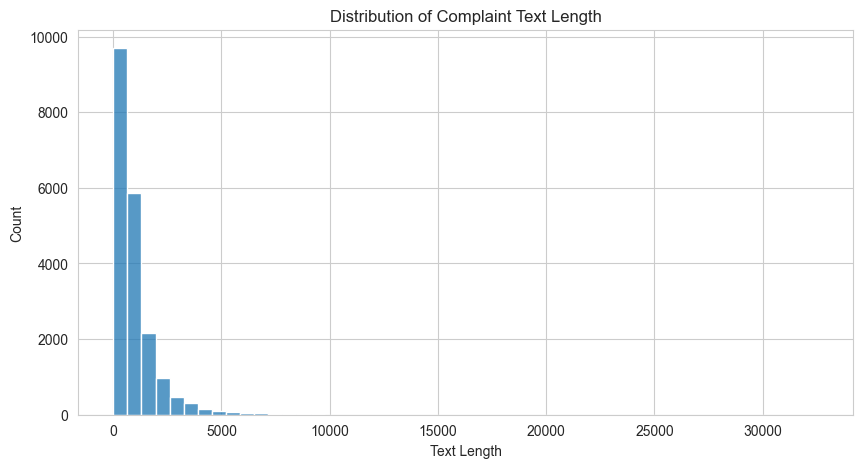

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(complaints["text_length"], bins=50)
plt.title("Distribution of Complaint Text Length")
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.show()

Complaint narratives are sufficiently rich in content to support NLP analysis.  
Text length variability suggests that some complaints contain detailed customer context, which can help identify dissatisfaction drivers.

In [14]:
sia = SentimentIntensityAnalyzer()

In [15]:
def get_sentiment_score(text):
    return sia.polarity_scores(str(text))["compound"]

In [16]:
complaints["sentiment_score"] = complaints["complaint_text"].apply(get_sentiment_score)
complaints["sentiment_score"].describe()

count    20000.000000
mean        -0.022278
std          0.679816
min         -1.000000
25%         -0.715400
50%          0.000000
75%          0.625925
max          0.999900
Name: sentiment_score, dtype: float64

In [17]:
def categorize_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

complaints["sentiment_label"] = complaints["sentiment_score"].apply(categorize_sentiment)
complaints["sentiment_label"].value_counts()

sentiment_label
negative    9793
positive    9464
neutral      743
Name: count, dtype: int64

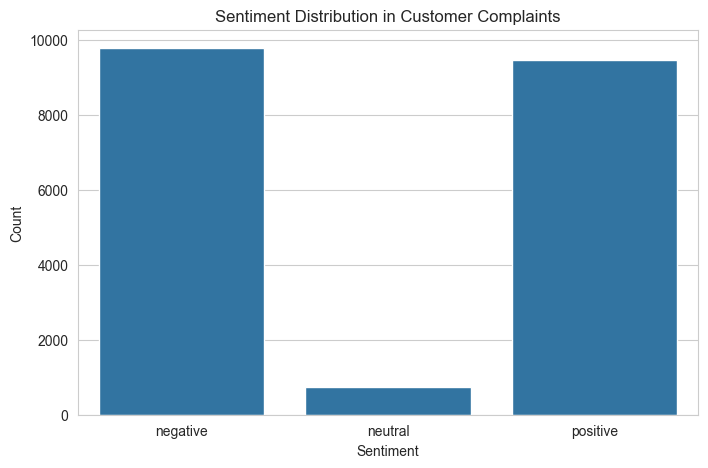

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(x="sentiment_label", data=complaints, order=["negative", "neutral", "positive"])
plt.title("Sentiment Distribution in Customer Complaints")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Most complaint narratives are expectedly negative, but sentiment scoring helps quantify dissatisfaction intensity.  
This score can later be reused as a predictive feature in churn modeling.

In [19]:
vectorizer = CountVectorizer(max_features=20)
X_counts = vectorizer.fit_transform(complaints["clean_text"])
word_counts = np.asarray(X_counts.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values(by="count", ascending=False)

freq_df

,word,count
19,xxxx,278146
7,credit,40742
0,account,28851
16,report,24726
12,information,24060
17,reporting,19533
6,consumer,19076
1,accounts,12546
14,payment,9241
9,debt,8436


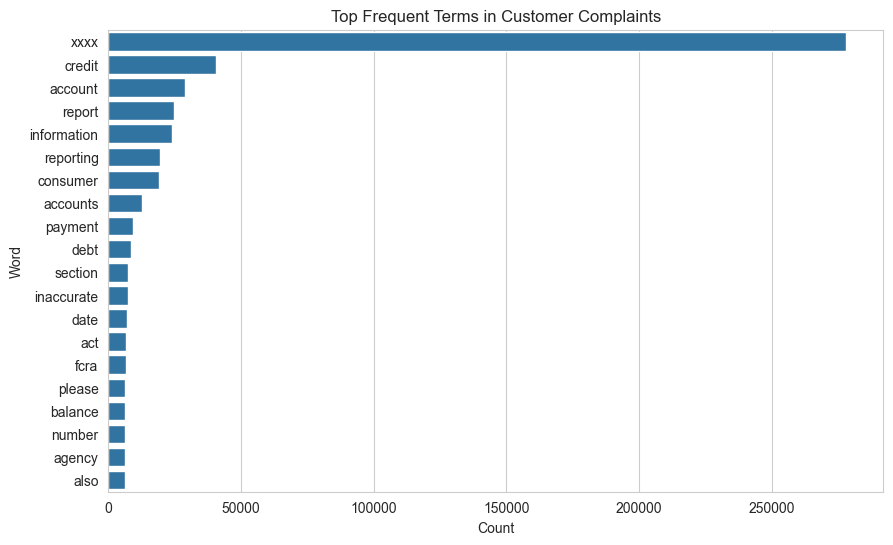

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=freq_df, x="count", y="word")
plt.title("Top Frequent Terms in Customer Complaints")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

Frequent terms provide a first indication of recurring customer pain points.  
These terms help identify which issues dominate the complaint landscape.

In [21]:
topic_vectorizer = CountVectorizer(max_df=0.95, min_df=5, stop_words="english")
X_topics = topic_vectorizer.fit_transform(complaints["clean_text"])

In [22]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_topics)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [23]:
def print_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx + 1}: {', '.join(top_features)}")

In [24]:
feature_names = topic_vectorizer.get_feature_names_out()
print_top_words(lda, feature_names)

Topic 1: xxxx, account, credit, xxxxxxxx, date, report, balance, accounts, number, inquiry
Topic 2: xxxx, account, payment, bank, late, card, payments, credit, balance, paid
Topic 3: xxxx, credit, loan, told, account, called, received, company, time, sent
Topic 4: credit, report, information, consumer, reporting, accounts, account, section, inaccurate, agency
Topic 5: debt, collection, account, xxxx, credit, provide, proof, information, request, letter


In [25]:
topic_results = lda.transform(X_topics)
complaints["dominant_topic"] = topic_results.argmax(axis=1)
complaints["dominant_topic"] = complaints["dominant_topic"] + 1
complaints[["clean_text", "dominant_topic"]].head()

,clean_text,dominant_topic
0,subject complaint pnc bank unresolved atm depo...,2
1,xxxx contact xxxx bank verify account showing ...,3
2,trader bitcoin platform xxxx opened venmo acco...,3
3,deposited check xxxx xxxx check amount limited...,2
4,filing complaint cash app block inc due inadeq...,2


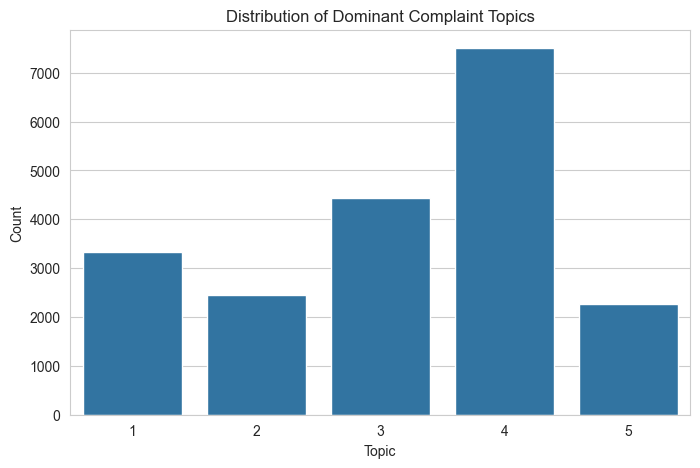

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(x="dominant_topic", data=complaints)
plt.title("Distribution of Dominant Complaint Topics")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.show()

Topic modeling groups complaint narratives into a small number of recurring issue families.  
This makes customer feedback more actionable for business and operational teams.

In [27]:
for topic_num in sorted(complaints["dominant_topic"].unique()):
    print(f"\n=== Topic {topic_num} ===")
    sample_texts = complaints[complaints["dominant_topic"] == topic_num]["complaint_text"].head(3)
    for txt in sample_texts:
        print("-", txt[:300])
        print()


=== Topic 1 ===
- I am a victim of identity theft. The following accounts are unauthorized and fraudulent : XXXX XXXX Bank and XXXX XXXX Bank. The following court document is fraudulent as well : XXXX XXXX XXXX XXXX : XXXX. The following inquiries are unauthorized and fraudulent : XXXX XXXX Bank, XXXX XXXX Bank, XXXX

- b'This complaint serves as a formal and legally binding demand for the immediate removal of fraudulent accounts associated with the unauthorized use of my Social Security number and personal information. These accounts were not opened, authorized, or consented to by me in any form and do not pertain

- I am writing to formally request the blocking and deletion of the following fraudulent accounts from my credit file. As a victim of a data breach, these accounts were added without my authorization. Under 15 U.S.C. 1681c-2 ( a ) and FCRA 605 ( b ), I am entitled to have these fraudulent items remove


=== Topic 2 ===
- Subject : Complaint Against PNC Bank for Unresolved 

### Topic interpretation

- **Topic 1**: payment delays and account servicing issues  
- **Topic 2**: credit reporting and disputes  
- **Topic 3**: customer service and communication failures  
- **Topic 4**: loan and repayment issues  
- **Topic 5**: fees, charges and unexpected account actions

In [28]:
nlp_features = complaints[[
    "product",
    "issue",
    "company",
    "state",
    "date_received",
    "complaint_text",
    "clean_text",
    "text_length",
    "sentiment_score",
    "sentiment_label",
    "dominant_topic"
]].copy()

nlp_features.to_csv("../data/processed/complaints_nlp_features.csv", index=False)
nlp_features.head()

,product,issue,company,state,date_received,complaint_text,clean_text,text_length,sentiment_score,sentiment_label,dominant_topic
0,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,PNC Bank N.A.,MD,2024-11-25,Subject : Complaint Against PNC Bank for Unres...,subject complaint pnc bank unresolved atm depo...,1666,-0.9868,negative,2
1,Credit reporting or other personal consumer re...,Incorrect information on your report,"EQUIFAX, INC.",LA,2023-11-21,XXXX contact XXXX bank to verify an account th...,xxxx contact xxxx bank verify account showing ...,226,0.6369,positive,3
2,"Money transfer, virtual currency, or money ser...",Unauthorized transactions or other transaction...,"Paypal Holdings, Inc",GA,2022-08-24,Im a trader of Bitcoin on the platform XXXX. I...,trader bitcoin platform xxxx opened venmo acco...,784,0.5070,positive,3
3,Checking or savings account,Managing an account,UNITED SERVICES AUTOMOBILE ASSOCIATION,NY,2021-11-11,I deposited a check to XXXX XXXX because the c...,deposited check xxxx xxxx check amount limited...,4873,-0.9935,negative,2
4,"Money transfer, virtual currency, or money ser...",Other transaction problem,"Block, Inc.",MO,2025-02-24,I am filing a complaint against cash app ( Blo...,filing complaint cash app block inc due inadeq...,653,-0.9852,negative,2


In [29]:
import joblib

joblib.dump(topic_vectorizer, "../models/vectorizer.pkl")
joblib.dump(lda, "../models/topic_model.pkl")

['../models/topic_model.pkl']

## Key findings

This NLP analysis shows that customer complaints contain actionable signals for customer experience monitoring.

Main takeaways:
- complaint narratives are rich enough for text analysis
- sentiment scores provide a measurable dissatisfaction signal
- recurring complaint themes can be grouped into operational issue families
- NLP-derived features such as sentiment, text length and dominant topic can be reused in downstream predictive models

These findings support the idea that customer voice can be transformed into structured data to improve decision-making and retention strategies.